In [1]:
import os
os.environ["PYMBAR_SOLVER"] = "scipy"  # Disable JAX JIT overhead for fast PyMBAR solving
import sys, re, glob
from math import ceil
import numpy as np
import pandas as pd
import seaborn as sb
from scipy.spatial.transform import Rotation as R
from scipy import stats
from scipy.special import logsumexp
import mdtraj as md
import tables as tb
import nglview as nv
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import Play, IntSlider, HBox, VBox, Label, ToggleButtons, link
import pymbar.utils, pymbar.mbar
def _lse(a, axis=None, b=None, use_numexpr=False):
    return logsumexp(a, axis=axis, b=b)
pymbar.utils.logsumexp = pymbar.mbar.logsumexp = _lse
import pymbar

upside_home = os.environ["UPSIDE_HOME"] #fme
upside_utils_dir = os.path.join(upside_home, "py3", "py") if os.path.exists(os.path.join(upside_home, "py3", "py")) else os.path.join(upside_home, "py")
if upside_utils_dir not in sys.path:
    sys.path.append(upside_utils_dir)
import mdtraj_upside as mu
import subprocess as sp

base_dir = os.path.join(os.getcwd(), os.pardir, "simulations", "upside", "nug2b") + "/"
up_indir = base_dir + "inputs/hdx/"
pdb_id = "nug2b" #fme
n_rep = 20 #fme

output_dir = base_dir + "outputs/remd_077_093_linear_ri10/" #fme

init_fn = up_indir + "{}.initial.npy".format(pdb_id)
fasta_fn = up_indir + "{}.fasta".format(pdb_id)
chain_breaks_fn = up_indir + "{}.chain_breaks".format(pdb_id)
if not os.path.exists(chain_breaks_fn):
    chain_breaks_fn = ""

# Each .run.N.up is a fixed-temperature REMD *slot*, not one walker. Neighbouring frames are unrelated
# load_upside_rep demultiplexes to follow a single replica.
run_fns = sorted(glob.glob(output_dir + "/{}.run.[0-9]*.up".format(pdb_id)),
                 key=lambda f: int(re.search(r"run\.(\d+)\.up$", f).group(1)))
rep_select = 0
traj = mu.load_upside_rep(run_fns, rep_select)

print(traj)

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



Very Important: All distances are in nanometers for MDTraj
<mdtraj.Trajectory with 41800 frames, 332 atoms, 56 residues, without unitcells>


In [2]:
# Remove global tumbling/translation so the animation shows conformational change.
ca_idx = traj.top.select("name CA")
traj.superpose(traj, 0, atom_indices=ca_idx)

acid_sele = traj.top.select("(resname ASP or resname GLU) and name CA")
base_sele = traj.top.select("(resname LYS or resname ARG) and name CA")


# DSSP calculation & Secondary Structure colors
dssp = md.compute_dssp(traj, simplified=True)
dssp_colors = {"H": "#ff2255", "E": "#0099ff", "C": "#aaaaaa"}

view = nv.NGLWidget()
view.add_trajectory(traj, default_representation=False)
view.camera = "orthographic"
view.parameters = {"clipNear": -100, "clipFar": 1000, "fogNear": 0, "fogFar": 1000}
view._iplayer.close()

mode_toggle = ToggleButtons(
    options=["Acid/Base", "DSSP Secondary Structure"],
    description="View Mode:",
    button_style="",
)

def update_representation(frame_idx=0):
    view.clear_representations()
    if mode_toggle.value == "Acid/Base":
        view.add_cartoon(color="#888888")
        view.add_spacefill(selection=acid_sele, color="#ff0000")
        view.add_spacefill(selection=base_sele, color="#0000ff")
    else:
        current_dssp = dssp[frame_idx]
        for ss_code, color in dssp_colors.items():
            res_seqs = [str(traj.top.residue(i).resSeq) for i, ss in enumerate(current_dssp) if ss == ss_code]
            if res_seqs:
                view.add_cartoon(selection=" or ".join(res_seqs), color=color)

n_frames = traj.n_frames
view.max_frame = n_frames - 1

player = Play(value=0, min=0, max=n_frames - 1, step=1, interval=100)
slider = IntSlider(value=0, min=0, max=n_frames - 1, continuous_update=True, readout=False, layout={"width": "400px"})
readout = Label(value="frame 0 / {}".format(n_frames - 1))

link((player, "value"), (slider, "value"))
link((slider, "value"), (view, "frame"))

def on_frame_change(change):
    frame = change["new"]
    readout.value = "frame {} / {}".format(frame, n_frames - 1)
    if mode_toggle.value == "DSSP Secondary Structure":
        update_representation(frame)

slider.observe(on_frame_change, names="value")
mode_toggle.observe(lambda c: update_representation(slider.value), names="value")

# Initial coloring
update_representation(0)

VBox([mode_toggle, view, HBox([player, slider, readout])])


---
# HDX from Peng protocol

The logic, in order:

1. **Load** each replica's energy, folding coordinate, and per-frame protection state.
2. **Pool** every replica into one reweightable ensemble with MBAR.
3. **Pick the analysis temperature** — where simulated global stability matches experiment.
4. **Per-residue $\Delta G_{HX}$** there, censoring what the sampling cannot resolve.
5. **Denaturant dependence** and m-values.

Protection states were generated with

```
python $UPSIDE_HOME/py/get_protection_state.py \
    <protection_states>/nug2b-HDX.up  <run_dir>/nug2b.run.<i>.up \
    <protection_states>/nug2b_<i>_PS.npy --residue <...>/nug2b.resid
```

The topology must be configured with `use_heavy_atom_coverage=True`; the run
files themselves lack `hbbb_coverage` and cannot be used as their own topology.

In [3]:

PS_DIR  = output_dir + "protection_states/"
# ri500 comparison run:  _BASE + "remd_077_093_lin/remd_077_093_linear/"

#fme
START_FRAME  = 500       # equilibration discard (Peng: 500 for mini-proteins)
T_REF_298    = 0.85      # ff_2.1: the reduced T corresponding to 298 K
R_GAS        = 0.001987  # kcal/mol/K
UNFOLDED_CUT = 38        # N_hbond below this = unfolded (minimum between the modes)
                         # run the cell bellow and calibrate to seperate between the two bimodals
RESID_OFFSET = 2         # PS column j  ->  experimental residue j + RESID_OFFSET


# Reuse existing notebook variables with your exact PS_DIR
HDX_TOP = f"{up_indir}{pdb_id}-HDX.up"
RESIDUE_FILE = f"{PS_DIR}{pdb_id}_stride1.resid"
os.makedirs(PS_DIR, exist_ok=True)

In [ ]:
# Compute protection states for each replica using PS_DIR
os.environ['PATH'] = os.path.dirname(sys.executable) + ':' + os.environ.get('PATH', '')

with tb.open_file(run_fns[0]) as t:
    seq_run = len(t.root.input.sequence[:])

def get_seq_len(fn):
    if not os.path.exists(fn): return None
    with tb.open_file(fn) as t:
        return len(t.root.input.sequence[:]) if 'sequence' in t.root.input else None

hdx_top_fn = os.path.join(PS_DIR, f'{pdb_id}-HDX.up')
if get_seq_len(hdx_top_fn) != seq_run:
    if get_seq_len(HDX_TOP) == seq_run:
        hdx_top_fn = HDX_TOP
    elif get_seq_len(os.path.join(base_dir, 'inputs', f'{pdb_id}.up')) == seq_run:
        hdx_top_fn = os.path.join(base_dir, 'inputs', f'{pdb_id}.up')

sim_id = os.path.basename(os.path.normpath(output_dir))

for i, traj_fn in enumerate(run_fns):
    out_ps_npy = os.path.join(PS_DIR, f'{pdb_id}_{sim_id}_stride1_{i}_PS.npy')
    cmd = [
        sys.executable, os.path.join(upside_utils_dir, 'get_protection_state.py'),
        hdx_top_fn, traj_fn, out_ps_npy,
        '--residue', RESIDUE_FILE
    ]
    sp.check_call(cmd)


In [7]:
run_fns = sorted(glob.glob(output_dir + 'remd_lowtemp/{}.run.[0-9]*.up'.format(pdb_id)),
                 key=lambda f: int(re.search(r'run\.(\d+)\.up$', f).group(1)))
n_rep = len(run_fns)
Pot = []
T = []
PS = []
for i, fn in enumerate(run_fns):
    with tb.open_file(fn) as t:
        temp = float(t.root.output.temperature[0,0])
        pot = np.array(t.root.output.potential[:]).flatten()
    ps_fn = f'{PS_DIR}/{pdb_id}_remd_lowtemp_stride1_{i}_PS.npy'
    ps = np.load(ps_fn)


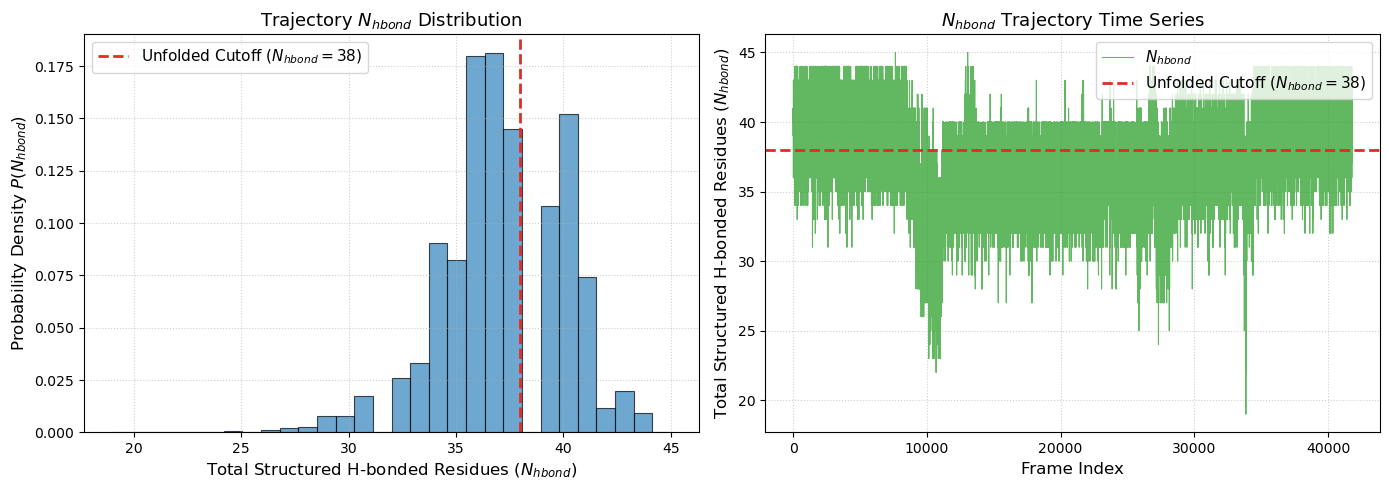

In [24]:
# Compute structured H-bonded residues per frame (Helix + Sheet) in ~0.05s
if 'dssp' not in globals():
    dssp = md.compute_dssp(traj, simplified=True)

hbond_counts = ((dssp == 'H') | (dssp == 'E')).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Probability Density P(N_hbond) & Unfolded Cutoff
counts, bins, _ = axes[0].hist(
    hbond_counts, bins=30, density=True,
    color='#3182bd', alpha=0.7, edgecolor='black', linewidth=0.8
)
axes[0].axvline(UNFOLDED_CUT, color='#de2d26', linestyle='--', linewidth=2,
                label=f'Unfolded Cutoff ($N_{{hbond}} = {UNFOLDED_CUT}$)')
axes[0].set_xlabel(r'Total Structured H-bonded Residues ($N_{hbond}$)', fontsize=12)
axes[0].set_ylabel(r'Probability Density $P(N_{hbond})$', fontsize=12)
axes[0].set_title(r'Trajectory $N_{hbond}$ Distribution', fontsize=13)
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Panel 2: Trajectory Frame vs N_hbond Time Series
axes[1].plot(hbond_counts, color='#2ca02c', alpha=0.75, linewidth=0.8, label=r'$N_{hbond}$')
axes[1].axhline(UNFOLDED_CUT, color='#de2d26', linestyle='--', linewidth=2,
                label=f'Unfolded Cutoff ($N_{{hbond}} = {UNFOLDED_CUT}$)')
axes[1].set_xlabel('Frame Index', fontsize=12)
axes[1].set_ylabel(r'Total Structured H-bonded Residues ($N_{hbond}$)', fontsize=12)
axes[1].set_title(r'$N_{hbond}$ Trajectory Time Series', fontsize=13)
axes[1].legend(fontsize=11, loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


## 1. Load

One `.up` per replica (a fixed-temperature *slot*, not a single walker) plus its
protection-state array. Frame counts differ slightly between replicas, so
everything is truncated to the common length.

In [9]:
def to_kelvin(t_red):
    return t_red * 298.0 / T_REF_298

# NuG2b experiment (Skinner et al.). These are the comparison targets; the two
# global numbers below are consumed as CALIBRATION, not predicted.
SKINNER_DG    = {3: 8.08, 4: 8.54, 5: 8.31, 6: 8.09, 7: 7.84, 16: 7.85,
                 18: 7.85, 26: 8.45, 27: 7.74, 30: 7.93, 31: 7.94, 51: 8.30}
DG_GLOBAL_EXP = 7.78     # kcal/mol (kinetics; CD gives 7.48)
M_VALUE_EXP   = 1.29     # kcal/mol/M

run_files = sorted(glob.glob(output_dir + "nug2b.run.[0-9]*.up"),
                   key=lambda f: int(re.search(r"run\.(\d+)\.up$", f).group(1)))

temps, energy, nhbond, protect = [], [], [], []
for i, fn in enumerate(run_files):
    with tb.open_file(fn) as t:
        temps.append(float(t.root.output.temperature[0, 0]))
        energy.append(np.asarray(t.root.output.potential[:]).ravel())
        hb = t.root.output.hbond
        nhbond.append(np.asarray(hb[:]).reshape(hb.shape[0], -1).sum(1))
    protect.append(np.load(PS_DIR + "nug2b_%d_PS.npy" % i))

n_common = min(min(len(e) for e in energy), min(p.shape[0] for p in protect))

T  = np.array(temps)
E  = np.stack([e[:n_common] for e in energy])[:, START_FRAME:]     # (K, N)
NH = np.stack([h[:n_common] for h in nhbond])[:, START_FRAME:]     # (K, N)
PS = np.stack([p[:n_common] for p in protect])[:, START_FRAME:]    # (K, N, n_res)

n_rep, n_per_rep, n_res = PS.shape
residues = np.arange(n_res) + RESID_OFFSET

print("%d replicas, T = %.3f..%.3f  (%.0f..%.0f K)"
      % (n_rep, T.min(), T.max(), to_kelvin(T.min()), to_kelvin(T.max())))
print("%d frames/replica after discarding %d  ->  %d samples, %d NH donors"
      % (n_per_rep, START_FRAME, n_rep * n_per_rep, n_res))

# The ladder must span the denaturation profile, or MBAR has no open states to
# reweight from. This is the precondition for everything below.
print("\nladder coverage:")
for k in range(n_rep):
    print("  T=%.4f (%5.1f K)   N_hbond %5.1f   unfolded %6.1f%%   protected NH %4.1f"
          % (T[k], to_kelvin(T[k]), NH[k].mean(),
             100 * (NH[k] < UNFOLDED_CUT).mean(), PS[k].sum(1).mean()))

16 replicas, T = 0.770..0.930  (270..326 K)
41300 frames/replica after discarding 500  ->  660800 samples, 55 NH donors

ladder coverage:
  T=0.7700 (270.0 K)   N_hbond  56.8   unfolded    0.0%   protected NH 43.0
  T=0.7807 (273.7 K)   N_hbond  56.6   unfolded    0.0%   protected NH 42.9
  T=0.7913 (277.4 K)   N_hbond  56.4   unfolded    0.0%   protected NH 42.9
  T=0.8020 (281.2 K)   N_hbond  56.2   unfolded    0.0%   protected NH 42.9
  T=0.8127 (284.9 K)   N_hbond  55.9   unfolded    0.0%   protected NH 42.9
  T=0.8233 (288.6 K)   N_hbond  55.7   unfolded    0.0%   protected NH 42.8
  T=0.8340 (292.4 K)   N_hbond  55.4   unfolded    0.0%   protected NH 42.8
  T=0.8447 (296.1 K)   N_hbond  55.2   unfolded    0.0%   protected NH 42.8
  T=0.8553 (299.9 K)   N_hbond  54.9   unfolded    0.0%   protected NH 42.8
  T=0.8660 (303.6 K)   N_hbond  54.5   unfolded    0.0%   protected NH 42.7
  T=0.8767 (307.4 K)   N_hbond  54.1   unfolded    0.1%   protected NH 42.6
  T=0.8873 (311.1 K)   N_h

## 2. Pool the replicas

MBAR merges every replica into a single ensemble that can be reweighted to any
temperature. Samples from the hot rungs are what make the open state accessible
at the cold analysis temperature — no single replica contains both.

The self-consistency check is the one that matters: reweighting back to a
*sampled* temperature must reproduce that replica's own average. Frames are
strongly correlated, so the comparison uses block standard errors — a naive
standard error understates the uncertainty by ~10x and makes this look broken
when it is fine.

In [ ]:
N_k  = np.full(n_rep, n_per_rep, np.int64)
beta = 1.0 / T

# u_kln[k, l, n] = reduced potential of replica k's frame n evaluated at temperature l
mbar = pymbar.MBAR(np.ascontiguousarray(beta[None, :, None] * E[:, None, :]), N_k)

# MBAR denominator, shared by every reweighting target
_log_denom = logsumexp(mbar.f_k[:, None] - beta[:, None] * E.reshape(1, -1),
                       b=N_k[:, None].astype(float), axis=0)

E_flat  = E.ravel()
NH_flat = NH.ravel()
IS_OPEN = (PS.reshape(-1, n_res) == 0)          # (N_total, n_res)
N_CLOSED = PS.reshape(-1, n_res).sum(1, dtype=np.int32)

def weights(t_red):
    """Normalised weight of every pooled frame in the ensemble at t_red."""
    log_w = -(E_flat / t_red) - _log_denom
    w = np.exp(log_w - log_w.max())
    return w / w.sum()

def block_se(x, n_blocks=40):
    b = len(x) // n_blocks
    means = [x[i * b:(i + 1) * b].mean() for i in range(n_blocks)]
    return np.std(means, ddof=1) / np.sqrt(n_blocks)

z = [(np.sum(weights(T[k]) * E_flat) - E[k].mean()) / block_se(E[k])
     for k in range(n_rep)]
print("MBAR self-consistency on <E>:  rms|z| = %.2f   max|z| = %.2f   (want O(1))"
      % (np.sqrt(np.mean(np.square(z))), np.max(np.abs(z))))

## 3. Choose the analysis temperature

Peng selects, per protein, the temperature at which the *simulated* global
stability equals the experimental one. That temperature is a calibration input,
not a prediction. It must land inside the ladder — Fig. S25 of the paper shows
what happens when you extrapolate below it.

In [ ]:
def global_stability(t_red, w=None):
    """dG between the folded and unfolded populations, kcal/mol."""
    w = weights(t_red) if w is None else w
    p_unf = w[NH_flat < UNFOLDED_CUT].sum()
    if not 0.0 < p_unf < 1.0:
        return np.nan
    return R_GAS * to_kelvin(t_red) * np.log((1.0 - p_unf) / p_unf)

t_scan  = np.arange(T.min(), T.max() + 1e-9, 0.005)
dg_scan = np.array([global_stability(t) for t in t_scan])
ok      = np.isfinite(dg_scan)

T_MELT     = float(np.interp(0.0, -dg_scan[ok], t_scan[ok]))
T_ANALYSIS = float(np.interp(-DG_GLOBAL_EXP, -dg_scan[ok], t_scan[ok]))

print("melting midpoint   T = %.4f  (%.1f K)" % (T_MELT, to_kelvin(T_MELT)))
print("stability-matched  T = %.4f  (%.1f K)   [dG_global = %.2f]"
      % (T_ANALYSIS, to_kelvin(T_ANALYSIS), DG_GLOBAL_EXP))
print("inside the ladder: %s" % (T.min() <= T_ANALYSIS <= T.max()))

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.plot(t_scan, dg_scan, color="#1f77b4")
ax.axhline(DG_GLOBAL_EXP, ls="--", c="#999", lw=1, label="experiment")
ax.axvline(T_ANALYSIS, ls="--", c="#d62728", lw=1, label="analysis T")
ax.axhline(0, c="#ccc", lw=0.8)
ax.set_xlabel("reduced temperature")
ax.set_ylabel(r"$\Delta G_{global}$ (kcal/mol)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 4. Per-residue $\Delta G_{HX}$

$\Delta G_{HX} = RT\,\ln(p_{\rm prot}/p_{\rm open})$.

Two things this cell is careful about:

- $p_{\rm open}$ is summed **directly over open frames**. Computing it as
  $1 - \langle PS\rangle$ is catastrophic cancellation for strongly protected
  residues, and the roundoff lands *above* the experimental answer — it looks
  like success.
- Resolvability is judged by `ess_open`, the effective number of *open* samples
  behind each residue — not by $RT\ln(\rm ESS)$, which is too strict (ΔG_global
  itself comes from $p_{\rm unf}\approx6\times10^{-7}$, far below $1/\rm ESS$).
  Unconverged residues are labelled, never clipped; one never seen open would get
  a one-sided Poisson bound instead of a number.

In [ ]:
n_open_raw = IS_OPEN.sum(0)     # unweighted: does this residue ever open at all?

def hdx(w, t_red):
    RT       = R_GAS * to_kelvin(t_red)
    p_open   = np.empty(n_res)
    ess_open = np.zeros(n_res)
    for j in range(n_res):
        wj = w[IS_OPEN[:, j]]
        p_open[j] = wj.sum()
        if wj.size:
            ess_open[j] = wj.sum() ** 2 / np.sum(wj ** 2)
    ess = 1.0 / np.sum(w ** 2)
    with np.errstate(divide="ignore", invalid="ignore"):
        dg = RT * np.log1p(-p_open) - RT * np.log(p_open)
    return dict(dg=dg, p_open=p_open, ess=ess, ess_open=ess_open, RT=RT,
                bound=RT * np.log(ess / 3.0 - 1.0))   # 95% Poisson, zero events seen

w_analysis = weights(T_ANALYSIS)
H = hdx(w_analysis, T_ANALYSIS)

# Resolvability is set by ess_open -- the effective number of OPEN samples behind
# each residue -- NOT by RT*ln(ESS). That heuristic is too strict here: dG_global
# itself is computed from p_unfolded ~ 6e-7, far below 1/ESS, because the rare
# frames carry small but well-determined weight.
resolved = (n_open_raw >= 5) & (H["ess_open"] >= 5)
censored = n_open_raw == 0

# Exchange route, judged on the directly-sampled folded ensemble (coldest rung,
# no reweighting). A residue that opens there has a local channel, which caps its
# dG_HX regardless of global stability. Require >=10 open frames: a handful is
# not distinguishable from none, and the observed distribution has a clean gap --
# local-channel residues show 66-1314 open frames of 41300, the rest show 0-4.
coldest     = int(np.argmin(T))
n_open_cold = (PS[coldest] == 0).sum(0)
local       = n_open_cold >= 10

print("T = %.4f   RT = %.4f   ESS = %.0f   ESS_unfolded = %.1f"
      % (T_ANALYSIS, H["RT"], H["ess"],
         (lambda u: u.sum() ** 2 / np.sum(u ** 2))(w_analysis[NH_flat < UNFOLDED_CUT])))
print("%d/%d residues resolved, %d unconverged, %d censored\n"
      % (resolved.sum(), n_res, (~resolved & ~censored).sum(), censored.sum()))

print(" res   exp     sim   ess_open  n_open_cold  status        route")
meas = np.array(sorted(SKINNER_DG))
for r in meas:
    j = r - RESID_OFFSET
    status = ("resolved" if resolved[j]
              else ("censored" if censored[j] else "unconverged"))
    print("  %3d   %.2f  %6.2f  %8.1f  %11d  %-12s  %s"
          % (r, SKINNER_DG[r], H["dg"][j], H["ess_open"][j], n_open_cold[j],
             status, "local" if local[j] else "global"))

# Group statistics over RESOLVED residues only -- an unconverged value is not a
# measurement and must not enter an RMSE.
sim = H["dg"][meas - RESID_OFFSET]
exp = np.array([SKINNER_DG[r] for r in meas])
res_mask = resolved[meas - RESID_OFFSET]
print()
for label, grp in (("global unfolding only", ~local[meas - RESID_OFFSET]),
                   ("spurious local channel", local[meas - RESID_OFFSET])):
    m, n_bad = grp & res_mask, (grp & ~res_mask).sum()
    if m.sum():
        d = sim[m] - exp[m]
        print("  %-24s resolved n=%d  RMSE %.2f  bias %+.2f   (+%d unconverged)"
              % (label, m.sum(), np.sqrt((d ** 2).mean()), d.mean(), n_bad))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

colour = np.where(local, "#d62728", "#1f77b4")

ax = axes[0]
ax.bar(residues, H["dg"], color=colour, width=0.85)
ax.bar(residues[~resolved], H["dg"][~resolved], color="none",
       edgecolor="k", hatch="///", width=0.85, lw=0.6, label="unconverged")
ax.plot(meas, exp, "k*", ms=9, ls="none", label="experiment")
ax.set_xlabel("residue"); ax.set_ylabel(r"$\Delta G_{HX}$ (kcal/mol)")
ax.set_title("blue = global route, red = local channel", fontsize=10)
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
m_loc, m_res = local[meas - RESID_OFFSET], resolved[meas - RESID_OFFSET]
for msk, col, lbl in ((~m_loc, "#1f77b4", "global route"),
                      (m_loc, "#d62728", "local channel")):
    ax.plot(exp[msk & m_res], sim[msk & m_res], "o", c=col, label=lbl)
    ax.plot(exp[msk & ~m_res], sim[msk & ~m_res], "o", mfc="none", mec=col)
lim = [0, max(sim.max(), exp.max()) * 1.1]
ax.plot(lim, lim, "-", c="#ccc", lw=1)
for r, x, y in zip(meas, exp, sim):
    ax.annotate(str(r), (x, y), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlim(7.0, 9.0); ax.set_ylim(lim)
ax.set_xlabel("experiment (kcal/mol)"); ax.set_ylabel("simulation (kcal/mol)")
ax.set_title("open markers = unconverged", fontsize=10)
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

## 5. Denaturant dependence

Peng destabilises each conformation in proportion to its number of protected
NH: $\Delta\Delta G([den]) = -s\,N_{\rm closed}\,[den]$, applied as a second
reweighting layer on top of the MBAR weights. $s$ is calibrated per protein to
reproduce the experimental m-value (Table S4: 0.038–0.068).

**This calibration fails here, and not for want of sampling.** The lever is
$\Delta N_{\rm closed}$ between the folded and the *reweighted unfolded*
ensemble, since $m = s\,\Delta N_{\rm closed}\,c$ with $c=0.697$ kcal/mol per
Upside unit. Measured across 8x of trajectory length it goes 8.0 → 7.5 → 6.7 →
6.3 — *converging down* to ~6, not climbing toward the ~26 separating the cold
and hot rungs.

The reason is the distance from the melting point. Peng's analysis temperatures
sit 6–17 K below each protein's $T_m$ (Ub at 300 K with $T_m$ = 317 K). Here the
stability-matched temperature is ~40 K below $T_m$, because ff_2.1
under-stabilises NuG2b and you must go far down to reach ΔG = 7.78. At that
distance the only unfolded states carrying weight are marginally unfolded
($N_{\rm closed}\approx37$ vs 43 folded); the genuinely unfolded ones
($N_{\rm closed}\approx17$ at the hottest rung) are energetically inaccessible. A denaturant model
coupled to $N_{\rm closed}$ has almost no leverage.

In [ ]:
def weights_denatured(t_red, s, den, w0=None):
    w0 = weights(t_red) if w0 is None else w0
    w = np.exp(-s * N_CLOSED * den / t_red) * w0
    return w / w.sum()

s_grid = np.linspace(0.01, 0.30, 20)
m_grid = np.array([
    global_stability(T_ANALYSIS, weights_denatured(T_ANALYSIS, s, 0.0, w_analysis))
    - global_stability(T_ANALYSIS, weights_denatured(T_ANALYSIS, s, 1.0, w_analysis))
    for s in s_grid])

s_cal = float(np.interp(M_VALUE_EXP, m_grid, s_grid))

# The lever: m = s * dN_closed * 0.697.  Measure dN_closed directly.
_unf = NH_flat < UNFOLDED_CUT
_wf, _wu = w_analysis[~_unf], w_analysis[_unf]
dN_closed = ((_wf * N_CLOSED[~_unf]).sum() / _wf.sum()
             - (_wu * N_CLOSED[_unf]).sum() / _wu.sum())
dN_rungs = PS[int(np.argmin(T))].sum(1).mean() - PS[int(np.argmax(T))].sum(1).mean()

print("m_global at s=0.05: %.3f     experimental m: %.2f"
      % (np.interp(0.05, s_grid, m_grid), M_VALUE_EXP))
print("s needed to reach experiment: %.3f   (Peng Table S4: 0.038-0.068)" % s_cal)
print("dN_closed folded vs reweighted-unfolded: %.1f   (cold vs hot rung: %.1f)"
      % (dN_closed, dN_rungs))
print("T_analysis is %.0f K below T_melt   (Peng's proteins: 6-17 K below)"
      % (to_kelvin(T_MELT) - to_kelvin(T_ANALYSIS)))
if not 0.03 <= s_cal <= 0.08:
    print("\n  NOT a sampling problem: dN_closed converges DOWN with more data")
    print("  (8.0 -> 7.5 -> 6.7 -> 6.3 over 8x trajectory length). Analysing this")
    print("  far below T_melt leaves only marginally-unfolded states with weight,")
    print("  so a denaturant model coupled to N_closed has no leverage. See above.")

den = np.array([0.0, 0.5, 1.0, 2.0, 3.0])
curves = np.array([hdx(weights_denatured(T_ANALYSIS, s_cal, d, w_analysis),
                       T_ANALYSIS)["dg"] for d in den])

fig, ax = plt.subplots(figsize=(5.5, 3.4))
for r in meas:
    j = r - RESID_OFFSET
    ax.plot(den, curves[:, j], "-o", ms=3,
            c="#d62728" if local[j] else "#1f77b4", alpha=0.7)
ax.set_xlabel("[urea] (M)")
ax.set_ylabel(r"$\Delta G_{HX}$ (kcal/mol)")
ax.set_title("s = %.3f (uncalibrated)" % s_cal, fontsize=10)
plt.tight_layout()
plt.show()

m_values = (curves[0] - curves[2]) / 1.0     # slope over 0 -> 1 M
print("\n res   m_value   route")
for r in meas:
    j = r - RESID_OFFSET
    print("  %3d   %6.3f    %s" % (r, m_values[j], "local" if local[j] else "global"))

## What this run does and does not establish

**Works.** The ladder spans the denaturation profile, the stability-matched
temperature lands inside it, MBAR is self-consistent, and no residue is
censored. The two independent runs — exchange every 10 vs every 500 time units —
agree on the melting midpoint to 0.003 and on the matched temperature to 0.01 in
reduced units, so the global-stability half of the result is solid.

**Result.** Ten of the twelve measured residues are resolved, and they split by
exchange route, judged by whether they ever open in the directly-sampled folded
ensemble:

- **Global route** (5, 6, 7, 16) — never open when folded. Resolved at 4.6–6.2
  kcal/mol, RMSE 2.48 and bias −2.40 against experiment. Comparable in kind to
  the 1.2–1.3 kcal/mol shortfall Peng reports for his own most stable NHs.
- **Local channel** (3, 4, 18, 26, 27, 51) — open 1–5% of the time even when
  folded, which caps $\Delta G_{HX}$ at 1.8–3.4 against an experimental 7.7–8.5.
  This is the real discrepancy, and it is converged (`ess_open` of 1200–16000).
- **Unconverged** (30, 31) — `ess_open` of 1.6 and 2.9. Their printed values
  happen to sit near experiment, but they rest on one or two frames. Not
  measurements.

The local openings are genuine structural events, not threshold artefacts: in
those frames the H-bond score is exactly 0 and burial is ~0.4 against ~21 when
protected, and the result is insensitive to the burial cutoff over 3.0–6.0. So
this is a force-field finding — ff_2.1 gives NuG2b spurious fast fraying at the
β1 N-terminus and the β4 entry.

Because $\Delta G_{HX} = RT\ln(p_{\rm prot}/p_{\rm open})$, predicting 8 kcal/mol
needs $p_{\rm open}\approx 5\times10^{-7}$. A 1% spurious opening rate caps the
answer at 2.5 kcal/mol no matter how much sampling is added.

**On sampling.** Exchange interval and duration do different things, measured
here rather than assumed:

- Going from 500 to 10 time units gave 22x more round trips (135 → 2973) and
  **zero** extra unfolding events (5 either way). REMD exchange rate does not
  change how much *time* a walker spends above the transition — only how it is
  chunked — and barrier crossings scale with residence time. It did nearly double
  ESS_unfolded (17 → 33) through better-mixed weights, which is what unstuck
  residue 7.
- `ess_open` scales cleanly with length for residues 5, 6, 7, 16 but shows no
  trend at all for 30 and 31 (1.8 → 1.7 → 4.3 → 1.6 over 8x). More frames are
  not adding comparable open configurations for those two.
- Only 2 of 16 rungs sit above the transition, i.e. 12% of walker time, and it
  takes ~1.7e6 walker-time-units per unfolding event. Reshaping the ladder to put
  more rungs above $T_m$ would raise the event rate several-fold at the same cost;
  buying duration alone needs ~10x for ~50 events.

**Caveats.**

- Skinner's twelve values span only 7.74–8.54 with SE 0.11–0.17, so correlation
  across them is noise-dominated. RMSE and the route split are the meaningful
  metrics; Pearson r is not.
- `DG_GLOBAL_EXP` and `M_VALUE_EXP` are calibration inputs. Only the per-residue
  pattern is a prediction.
- The m-value calibration fails for a diagnosed, non-statistical reason (step 5).
- `UNFOLDED_CUT` is a substitution: Peng derives ΔG_global from an FES along
  H-bond count, and the exact two-state construction is not pinned down here.
  This feeds `T_ANALYSIS` and hence everything downstream.
- Peng's irreversible-unfolding truncation (keep the native→unfolded leg, drop
  frames after misfolded re-collapse at smoothed $R_g$ < 18 Å) is **not applied**.
  With refold/unfold at 0.40 the condition arguably holds; untested either way.

In [ ]:
# 1. Inputs relative to setup in the first notebook cell
output_dir = os.path.join(base_dir, 'outputs', 'remd_077_093_linear_ri10')
sim_id = os.path.basename(os.path.normpath(output_dir))
PS_DIR = os.path.join(output_dir, 'protection_states')
os.makedirs(PS_DIR, exist_ok=True)


In [ ]:
# 2. Topology check & per-replica protection state subprocess execution
os.environ['PATH'] = os.path.dirname(sys.executable) + ':' + os.environ.get('PATH', '')

run_fns = sorted(glob.glob(os.path.join(output_dir, f'{pdb_id}.run.[0-9]*.up')),
                 key=lambda f: int(re.search(r'run\.(\d+)\.up$', f).group(1)))

with tb.open_file(run_fns[0]) as t:
    seq_run = len(t.root.input.sequence[:])

def get_seq_len(fn):
    if not os.path.exists(fn): return None
    with tb.open_file(fn) as t:
        return len(t.root.input.sequence[:]) if 'sequence' in t.root.input else None

hdx_up_fn = os.path.join(PS_DIR, f'{pdb_id}-HDX.up')
if get_seq_len(hdx_up_fn) != seq_run:
    if get_seq_len(os.path.join(up_indir, f'{pdb_id}-HDX.up')) == seq_run:
        hdx_up_fn = os.path.join(up_indir, f'{pdb_id}-HDX.up')
    elif get_seq_len(os.path.join(base_dir, 'inputs', f'{pdb_id}.up')) == seq_run:
        hdx_up_fn = os.path.join(base_dir, 'inputs', f'{pdb_id}.up')

for i, traj_fn in enumerate(run_fns):
    out_ps_npy = os.path.join(PS_DIR, f'{pdb_id}_{sim_id}_stride1_{i}_PS.npy')
    residue_fn = os.path.join(PS_DIR, f'{pdb_id}_stride1.resid')
    cmd = [
        sys.executable, os.path.join(upside_utils_dir, 'get_protection_state.py'),
        hdx_up_fn, traj_fn, out_ps_npy,
        '--residue', residue_fn
    ]
    sp.check_call(cmd)
